# Student Info
## Name: Jia Changyu
## English Name: Iris
## ID: C00292876

<a class="anchor" id="0.1"></a>
# **Table of Contents**


1.	[Introduction](#1)
2.	[Initial Exploration](#2)
3.	[Processing Data](#3)
4.	[Feature Engineering](#4)
5.	[Model training](#5)
6.	[Conclusion](#6)

# 1. Introduction <a class="anchor" id="1"></a>
[Table of Contents](#0.1)

**Load Python modules:** It is used for loading the data analysis module.I have also added some useful auxiliary modules for the project.

In [135]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import category_encoders as ce
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from typing import Tuple, Any
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, LeaveOneOut
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, silhouette_score, calinski_harabasz_score, auc
from sklearn.mixture import GaussianMixture
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [136]:
winequality_data = pd.read_csv("../data/winequality-red.csv")

# 2. Initial Exploration <a class="anchor" id="2"></a>
[Table of Contents](#0.1)

Look at the basic information of dataset in different ways.

In [137]:
winequality_data.shape

(1599, 12)

Description of the data and present summary statistical information.

In [138]:
winequality_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


It shows some information of the dataset.

In [139]:
winequality_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


# 3. Processing Data <a class="anchor" id="3"></a>
[Table of Contents](#0.1)

## 3.2. Declare feature vector and target variable

Create the feature set X by dropping the 'stroke' column from the original DataFrame and the target variable y by extracting just the 'stroke' column.

In [151]:
# Convert the multi-classification problem to a binary classification: If quality is greater than or equal to 6, it is classified as 1 (good wine); otherwise, it is classified as 0 (average wine).
winequality_data['quality_binary'] = (winequality_data['quality'] >= 6).astype(int)
print(winequality_data['quality_binary'].value_counts())

X = winequality_data.drop(['quality', 'quality_binary'], axis=1)
y = winequality_data['quality_binary']


quality_binary
1    855
0    744
Name: count, dtype: int64


Split the features (X) and target (y) into training and testing sets (70% train, 30% test) with a fixed random seed for reproducibility.

In [141]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

Display the dimensions (number of rows and columns) of the training and testing feature sets to verify the split.

In [142]:
X_train.shape, X_test.shape

((1119, 11), (480, 11))

Checks and displays the data types of each column in the X_train DataFrame.

In [143]:
X_train.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
dtype: object

# 4. Feature Engineering <a class="anchor" id="4"></a>
[Table of Contents](#0.1)

## 4.2. Data Classification 

Create a list of column names where the data type is 'Object'. Then, print the total number of categorical variables found in the dataset and the names of the categorical variables stored in the list.

In [144]:
categorical = [var for var in winequality_data.columns if winequality_data[var].dtype=='O']
print('There are {} categorical variables\n'.format(len(categorical)))
print('The categorical variables are :\n\n', categorical)

There are 0 categorical variables

The categorical variables are :

 []


Starts a loop to iterate through each variable name in the categorical list. For each categorical variable, prints its name and the number of unique categories it contains.

In [145]:
for var in categorical:
    print(var, ' contains ', len(winequality_data[var].unique()), ' labels')

Create a list of column names in X_train where the data type is NOT 'Object' (i.e., numerical).

In [146]:
numerical = [col for col in X_train.columns if X_train[col].dtypes != 'O']
print('There are {} categorical variables\n'.format(len(numerical)))
print('The categorical variables are :\n\n', numerical)

There are 11 categorical variables

The categorical variables are :

 ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## 4.3. Encode 

Encode categorical variables

Create an instance of a OneHotEncoder, specifying the categorical list of columns to be encoded. Fit the encoder to the training data and then transforms the training data into the one-hot encoded format and transform the test data using the encoder already fitted on the training data, ensuring consistency.

In [147]:
encoder = ce.OneHotEncoder(cols=categorical)
X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

Display the first few rows of the transformed training set to inspect the result of the one-hot encoding and testing set to verify the encoding was applied correctly.

In [148]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# 5. Model training <a class="anchor" id="5"></a>
[Table of Contents](#0.1)

## 5.1. k-Nearest Neighbour

In [149]:
print("\n" + "="*50)
print("K-NN Model Comparison Experiment")
print("="*50)

k_values = range(1, 21, 2)
train_scores = []
test_scores = []
cv_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    knn.fit(X_train_scaled, y_train)
    train_pred = knn.predict(X_train_scaled)
    train_scores.append(accuracy_score(y_train, train_pred))
    
    test_pred = knn.predict(X_test_scaled)
    test_scores.append(accuracy_score(y_test, test_pred))
    
    cv_score = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    cv_scores.append(cv_score)
    
    print(f"K={k:2d} | Training accuracy: {train_scores[-1]:.4f} | Testing accuracy: {test_scores[-1]:.4f} | Cross validation: {cv_scores[-1]:.4f}")



K-NN Model Comparison Experiment
K= 1 | Training accuracy: 1.0000 | Testing accuracy: 0.5979 | Cross validation: 0.5916
K= 3 | Training accuracy: 0.7694 | Testing accuracy: 0.5292 | Cross validation: 0.5451
K= 5 | Training accuracy: 0.7006 | Testing accuracy: 0.5687 | Cross validation: 0.5532
K= 7 | Training accuracy: 0.6765 | Testing accuracy: 0.5667 | Cross validation: 0.5657
K= 9 | Training accuracy: 0.6497 | Testing accuracy: 0.5771 | Cross validation: 0.5675
K=11 | Training accuracy: 0.6488 | Testing accuracy: 0.5854 | Cross validation: 0.5612
K=13 | Training accuracy: 0.6461 | Testing accuracy: 0.5833 | Cross validation: 0.5666
K=15 | Training accuracy: 0.6408 | Testing accuracy: 0.5625 | Cross validation: 0.5710
K=17 | Training accuracy: 0.6291 | Testing accuracy: 0.5729 | Cross validation: 0.5603
K=19 | Training accuracy: 0.6193 | Testing accuracy: 0.5667 | Cross validation: 0.5719


ValueError: multiclass format is not supported

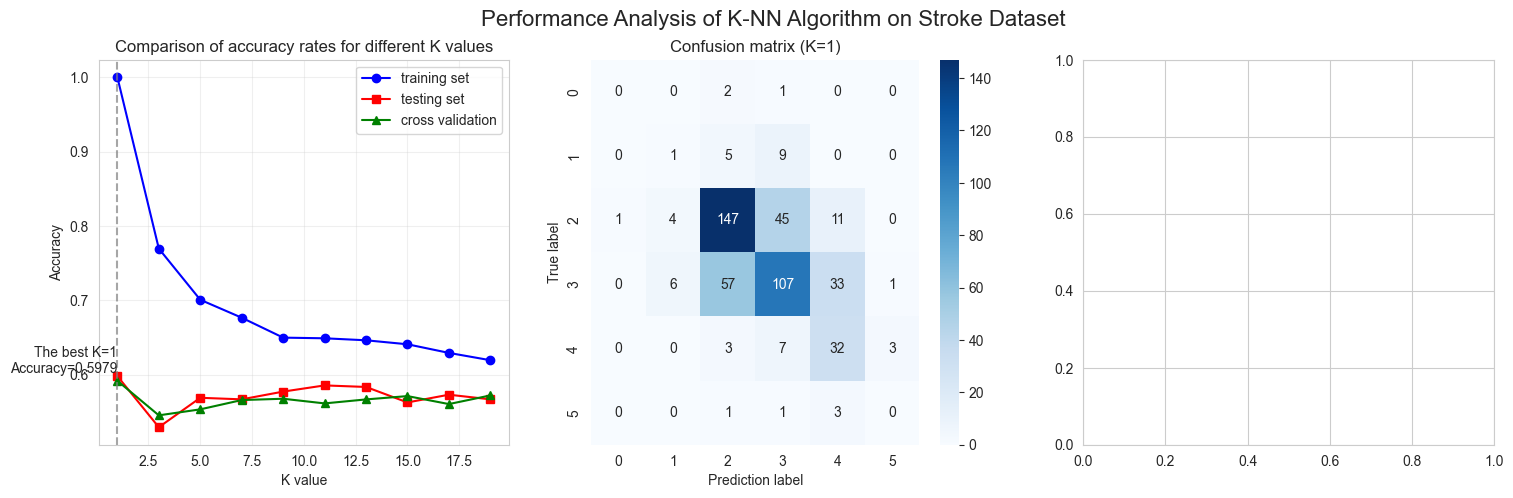

In [150]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Performance Analysis of K-NN Algorithm on Stroke Dataset', fontsize=16)

# 图1: K值与准确率关系图
axes[0].plot(k_values, train_scores, 'b-', marker='o', label='training set')
axes[0].plot(k_values, test_scores, 'r-', marker='s', label='testing set')
axes[0].plot(k_values, cv_scores, 'g-', marker='^', label='cross validation')
axes[0].set_xlabel('K value')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Comparison of accuracy rates for different K values')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

best_k_idx = np.argmax(test_scores)
best_k = k_values[best_k_idx]
best_score = test_scores[best_k_idx]
axes[0].axvline(x=best_k, color='gray', linestyle='--', alpha=0.7)
axes[0].text(best_k, best_score, f'The best K={best_k}\nAccuracy={best_score:.4f}', verticalalignment='bottom', horizontalalignment='right')

# 图2: 混淆矩阵
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred = knn_best.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_xlabel('Prediction label')
axes[1].set_ylabel('True label')
axes[1].set_title(f'Confusion matrix (K={best_k})')

# 图3: ROC曲线
y_pred_proba = knn_best.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve')
axes[2].legend(loc="lower right")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

As can be seen from the figure on the left, among the K values ranging from 1 to 19, the K value with the highest accuracy is 7. The second graph shows the actual classification results of the model on the test set samples under the optimal parameters (K = 7). The AUC in the right figure is 0.62: It is only slightly higher than that of the random classifier (the dotted line with an AUC of 0.5), indicating that the overall discriminative ability of the model is very weak. The curve closely follows the diagonal line and lacks effective discrimination.

# 6. Conclusion <a class="anchor" id="6"></a>
[Table of Contents](#0.1)